In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import (
    AllChem,
    Descriptors,
    Draw,
    MACCSkeys,
    PandasTools,
    rdFingerprintGenerator,
    rdMolDescriptors,
)
from rdkit.ML.Descriptors import MoleculeDescriptors

MOL_FILE = Path("morphine.mol")
EXCEL_FILE = Path("Heteroaromatics.xlsx")

In [103]:
def infos_molecule(mol_path: Path) -> Chem.Mol:
    mol = Chem.MolFromMolFile(str(mol_path), removeHs=False)
    if mol is None:
        raise ValueError(f"Impossible de lire la molécule depuis {mol_path}")

    symboles = [atom.GetSymbol() for atom in mol.GetAtoms()]

    print("Formula:", rdMolDescriptors.CalcMolFormula(mol))
    print("Molecular weight:", Descriptors.MolWt(mol))
    print("Number of atoms:", mol.GetNumAtoms())
    print("Number of bonds:", mol.GetNumBonds())
    print("Symboles des atomes :", symboles)
    print("Nombre d'azotes (N) :", symboles.count("N"))
    print("Nombre d'oxygènes (O) :", symboles.count("O"))
    print("Nombre de carbones (C) :", symboles.count("C"))

    logp = Descriptors.MolLogP(mol)
    if logp > 0:
        print("La molécule est hydrophobe / non polaire")
    elif logp == 0:
        print("La molécule est neutre")
    else:
        print("La molécule est hydrophile / polaire")

    print("Nombre de liaisons rotatives :", Descriptors.NumRotatableBonds(mol))
    print("SMILES canonique :", Chem.MolToSmiles(mol))
    return mol


def visualiser_2d(mol: Chem.Mol):
    mol2d = Chem.Mol(mol)
    AllChem.Compute2DCoords(mol2d)
    return Draw.MolToImage(mol2d, size=(600, 600))


def visualiser_3d(mol: Chem.Mol):
    import py3Dmol

    viewer = py3Dmol.view(width=600, height=500)
    viewer.addModel(Chem.MolToMolBlock(mol), "mol")
    viewer.setStyle({"stick": {}, "sphere": {"scale": 0.25}})
    viewer.setStyle({"elem": "N"}, {"stick": {"color": "purple"}, "sphere": {"color": "purple", "scale": 0.25}})
    viewer.setBackgroundColor("black")
    viewer.zoomTo()
    return viewer

In [104]:
mol = infos_molecule(MOL_FILE)
visualiser_3d(mol)

Formula: C17H19NO3
Molecular weight: 285.34299999999956
Number of atoms: 40
Number of bonds: 44
Symboles des atomes : ['C', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'O', 'C', 'O', 'C', 'C', 'O', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
Nombre d'azotes (N) : 1
Nombre d'oxygènes (O) : 3
Nombre de carbones (C) : 17
La molécule est hydrophobe / non polaire
Nombre de liaisons rotatives : 2
SMILES canonique : [H]Oc1c([H])c([H])c2c3c1O[C@]1([H])[C@]34C([H])([H])C([H])([H])N(C([H])([H])[H])[C@]([H])(C2([H])[H])[C@]4([H])C([H])=C([H])[C@]1([H])O[H]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [4]:
mol = infos_molecule(MOL_FILE)
visualiser_3d(mol)

Formula: C17H19NO3
Molecular weight: 285.34299999999956
Number of atoms: 40
Number of bonds: 44
Symboles des atomes : ['C', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'O', 'C', 'O', 'C', 'C', 'O', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
Nombre d'azotes (N) : 1
Nombre d'oxygènes (O) : 3
Nombre de carbones (C) : 17
La molécule est hydrophobe / non polaire
Nombre de liaisons rotatives : 2
SMILES canonique : [H]Oc1c([H])c([H])c2c3c1O[C@]1([H])[C@]34C([H])([H])C([H])([H])N(C([H])([H])[H])[C@]([H])(C2([H])[H])[C@]4([H])C([H])=C([H])[C@]1([H])O[H]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
MOLECULES_REF = {
    "Water": "O",
    "Methane": "C",
    "Ethanol": "CCO",
    "Acetic acid": "CC(=O)O",
    "Benzene": "c1ccccc1",
    "Toluene": "Cc1ccccc1",
    "Phenol": "Oc1ccccc1",
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine": "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Glucose": "OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O",
    "Morphine": "CN1CC[C@]23c4c5ccc(O)c4O[C@H]2[C@@H](O)C=C[C@H]3[C@H]1C5",
    "Cholesterol": "CC(C)CCCC(C)C1CCC2C1(CCC3C2CC=C4C3(CCC(C4)O)C)C",
    "Nicotine": "CN1CCC[C@H]1c1cccnc1",
    "Vitamin C": "OC[C@H](O)[C@H]1OC(=O)C(O)=C1O",
    "Dopamine": "NCCc1ccc(O)c(O)c1",
    "Serotonin": "NCCc1c[nH]c2ccc(O)cc12",
    "Adrenaline": "CNC[C@H](O)c1ccc(O)c(O)c1",
    "Cortisone": "CC12CCC(=O)C=C1CCC1C2C(=O)CC2(C)C1CCC2(O)C(=O)CO",
    "TNT": "Cc1c(cc(cc1[N+](=O)[O-])[N+](=O)[O-])[N+](=O)[O-]",
}


def construire_molecules_ref(smiles_dict: dict, sauvegarder_images: bool = False):
    mol_list = []
    for name, smiles in smiles_dict.items():
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print(f"SMILES invalide pour {name}, ignoré")
            continue
        mol_list.append((name, mol))
        print(f"{name}: {Chem.MolToSmiles(mol)}")

        if sauvegarder_images:
            AllChem.Compute2DCoords(mol)
            Draw.MolToImage(mol, size=(300, 300)).save(f"{name}.png")
    return mol_list

In [6]:
mol_list = construire_molecules_ref(MOLECULES_REF, sauvegarder_images=False)

Water: O
Methane: C
Ethanol: CCO
Acetic acid: CC(=O)O
Benzene: c1ccccc1
Toluene: Cc1ccccc1
Phenol: Oc1ccccc1
Aspirin: CC(=O)Oc1ccccc1C(=O)O
Caffeine: Cn1c(=O)c2c(ncn2C)n(C)c1=O
Paracetamol: CC(=O)Nc1ccc(O)cc1
Ibuprofen: CC(C)Cc1ccc(C(C)C(=O)O)cc1
Glucose: OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O
Morphine: CN1CC[C@]23c4c5ccc(O)c4O[C@H]2[C@@H](O)C=C[C@H]3[C@H]1C5
Cholesterol: CC(C)CCCC(C)C1CCC2C3CC=C4CC(O)CCC4(C)C3CCC12C
Nicotine: CN1CCC[C@H]1c1cccnc1
Vitamin C: O=C1O[C@H]([C@@H](O)CO)C(O)=C1O
Dopamine: NCCc1ccc(O)c(O)c1
Serotonin: NCCc1c[nH]c2ccc(O)cc12
Adrenaline: CNC[C@H](O)c1ccc(O)c(O)c1
Cortisone: CC12CCC(=O)C=C1CCC1C2C(=O)CC2(C)C1CCC2(O)C(=O)CO
TNT: Cc1c([N+](=O)[O-])cc([N+](=O)[O-])cc1[N+](=O)[O-]


In [7]:
def charger_dataframe_smiles(excel_path: Path, add_hs: bool = True) -> pd.DataFrame:
    df = pd.read_excel(excel_path)
    if "Smiles" not in df.columns:
        raise ValueError("Le fichier doit contenir une colonne 'Smiles'")

    mols, valid_mask, bad_smiles = [], [], []
    for s in df["Smiles"]:
        if pd.isna(s):
            valid_mask.append(False)
            continue
        mol = Chem.MolFromSmiles(str(s))
        if mol is None:
            bad_smiles.append(s)
            valid_mask.append(False)
            continue
        mols.append(Chem.AddHs(mol) if add_hs else mol)
        valid_mask.append(True)

    df = df[valid_mask].reset_index(drop=True)
    df["mol"] = mols

    print("Molécules valides :", len(mols))
    print("SMILES invalides ignorés :", len(bad_smiles))
    return df


def apercu_grille(df: pd.DataFrame, n: int = 8):
    return Draw.MolsToGridImage(df["mol"].tolist()[:n], molsPerRow=4, subImgSize=(200, 200))

Molécules valides : 14
SMILES invalides ignorés : 0


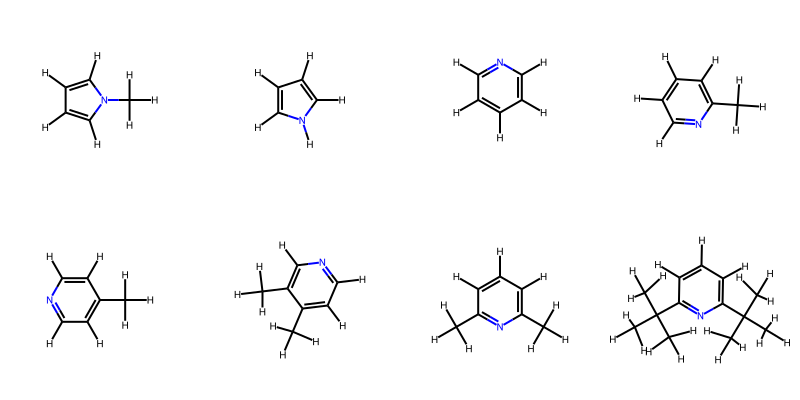

In [8]:
df = charger_dataframe_smiles(EXCEL_FILE, add_hs=True)
PandasTools.RenderImagesInAllDataFrames(images=True)
apercu_grille(df)

In [9]:
def calculer_fingerprints(df: pd.DataFrame, methode: str, n_bits: int = 2048) -> pd.DataFrame:
    generateurs = {
        "morgan": lambda: rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits),
        "rdkit": lambda: rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=n_bits),
        "atompair": lambda: rdFingerprintGenerator.GetAtomPairGenerator(fpSize=n_bits),
        "torsion": lambda: rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=n_bits),
    }

    lignes = []
    prefixe = methode.upper()
    for mol in df["mol"]:
        arr = np.zeros((n_bits,), dtype=np.int8)
        if mol is not None:
            if methode == "maccs":
                bv = MACCSkeys.GenMACCSKeys(mol)
                arr = np.zeros((bv.GetNumBits(),), dtype=np.int8)
                DataStructs.ConvertToNumpyArray(bv, arr)
            elif methode == "pattern":
                from rdkit.Chem import PatternFingerprint
                bv = PatternFingerprint(mol, fpSize=n_bits)
                DataStructs.ConvertToNumpyArray(bv, arr)
            elif methode == "avalon":
                from rdkit.Avalon import pyAvalonTools
                bv = pyAvalonTools.GetAvalonFP(mol, nBits=n_bits)
                DataStructs.ConvertToNumpyArray(bv, arr)
            elif methode in generateurs:
                bv = generateurs[methode]().GetFingerprint(mol)
                DataStructs.ConvertToNumpyArray(bv, arr)
            else:
                raise ValueError(f"Méthode inconnue : {methode}")
        lignes.append(arr)

    colonnes = [f"{prefixe}_{i}" for i in range(len(lignes[0]))]
    df_fp = pd.DataFrame(lignes, columns=colonnes)
    return pd.concat([df.reset_index(drop=True), df_fp], axis=1)


def resume_bits(df_fp: pd.DataFrame, row_idx: int, prefixe_colonnes_a_ignorer: int = 2):
    ligne = df_fp.iloc[row_idx, prefixe_colonnes_a_ignorer:]
    print(f"Nombre de bits à 1 : {(ligne == 1).sum()}")
    print(f"Nombre de bits à 0 : {(ligne == 0).sum()}")
    print(ligne[ligne == 1])

,Smiles,mol,MACCS_0,MACCS_1,MACCS_2,MACCS_3,MACCS_4,MACCS_5,MACCS_6,MACCS_7,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,CN1C=CC=C1,,0,0,0,0,0,0,0,0,...,0,1,0,1,1,1,0,0,1,0
1,C1=CC=CN1,,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,1,0
2,C1=CN=CC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,1,0
3,CC1=NC=CC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,0,1,0
4,CC1=CC=NC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,0,1,0

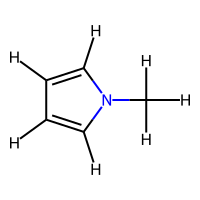
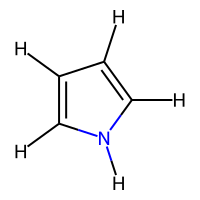
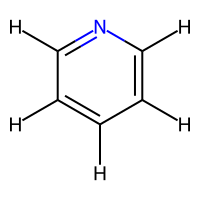
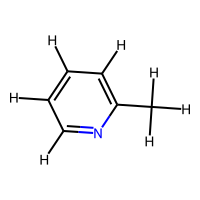
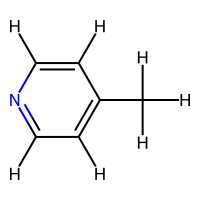

In [10]:
df_maccs = calculer_fingerprints(df, methode="maccs")
df_maccs.head()

In [11]:
df_morgan = calculer_fingerprints(df, methode="morgan", n_bits=2048)
resume_bits(df_morgan, row_idx=0)

Nombre de bits à 1 : 13
Nombre de bits à 0 : 2035
MORGAN_91      1
MORGAN_363     1
MORGAN_935     1
MORGAN_950     1
MORGAN_1057    1
MORGAN_1168    1
MORGAN_1460    1
MORGAN_1530    1
MORGAN_1564    1
MORGAN_1652    1
MORGAN_1863    1
MORGAN_1873    1
MORGAN_1992    1
Name: 0, dtype: object


In [12]:
df_avalon = calculer_fingerprints(df, methode="avalon", n_bits=512)
df_rdkit = calculer_fingerprints(df, methode="rdkit", n_bits=4096)
df_atompair = calculer_fingerprints(df, methode="atompair", n_bits=4096)
df_torsion = calculer_fingerprints(df, methode="torsion", n_bits=2048)

In [13]:
def calculer_descripteurs_un(mol: Chem.Mol, noms: list) -> dict:
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(noms)
    return dict(zip(noms, calc.CalcDescriptors(mol)))


def calculer_descripteurs_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    noms_descripteurs = [x[0] for x in Descriptors._descList]
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(noms_descripteurs)

    valeurs = [
        calc.CalcDescriptors(mol) if mol is not None else [np.nan] * len(noms_descripteurs)
        for mol in df["mol"]
    ]
    desc_df = pd.DataFrame(valeurs, columns=noms_descripteurs)
    return pd.concat([df.reset_index(drop=True), desc_df], axis=1)

,Smiles,mol,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,CN1C=CC=C1,,7.188079,7.188079,0.386574,-2.663426,0.439206,27.666667,81.118,74.062,...,0,0,0,0,0,0,0,0,0,0
1,C1=CC=CN1,,6.969907,6.969907,0.361111,-0.407407,0.465869,22.000000,67.091,62.051,...,0,0,0,0,0,0,0,0,0,0
2,C1=CN=CC=C1,,7.070741,7.070741,0.397222,-0.420370,0.453148,19.666667,79.102,74.062,...,0,0,0,0,0,0,0,0,0,0
3,CC1=NC=CC=C1,,7.275116,7.275116,0.525000,-2.614699,0.471998,24.857143,93.129,86.073,...,0,0,0,0,0,0,0,0,0,0
4,CC1=CC=NC=C1,,7.275116,7.275116,0.581019,-2.650093,0.471998,24.857143,93.129,86.073,...,0,0,0,0,0,0,0,0,0,0

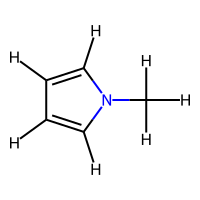
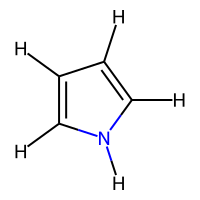
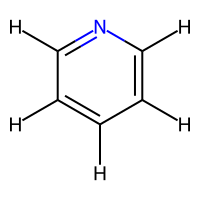
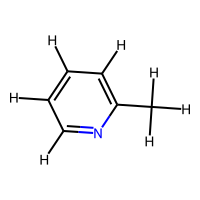
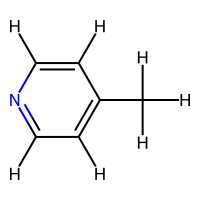

In [14]:
df_final = calculer_descripteurs_dataframe(df)
df_final.head()

In [15]:
def calculer_descripteurs_padel(df: pd.DataFrame, xml_dir: Path, smi_path: Path):
    import glob
    from padelpy import padeldescriptor

    df.to_csv(smi_path, index=None, header=None)
    resultats = {}
    for xml_file in sorted(glob.glob(str(xml_dir / "*.xml"))):
        out_csv = Path(xml_file).with_suffix(".csv")
        padeldescriptor(
            mol_dir=str(smi_path),
            d_file=str(out_csv),
            descriptortypes=xml_file,
            retainorder=True,
            fingerprints=True,
            d_2d=False,
            d_3d=False,
        )
        fp = pd.read_csv(out_csv)
        fp = pd.concat([df.reset_index(drop=True), fp.drop(columns="Name")], axis=1)
        fp.to_csv(out_csv, index=None)
        resultats[Path(xml_file).stem] = fp
        print(f"{Path(xml_file).stem} terminé")
    return resultats

In [16]:


df_alcohols = pd.read_excel(r'C:\Users\pc\Desktop\project\tutorial_rdkit\alcohols.xlsx')
df_alcohols.head(10)

,Name,Smiles
0,2-phenoxyethanol,OCCOC1=CC=CC=C1
1,2-bromoethanol,BrCCO
2,2-fluoroethanol,FCCO
3,methanol,CO
4,benzylalcohol,OCC1=CC=CC=C1
5,ethanol,CCO
6,1-phenylethanol,OC(C)C1=CC=CC=C1
7,2-phenylethanol,OCCC1=CC=CC=C1
8,2-methoxyethanol,OCCOC
9,2-ethoxyethanol,OCCOCC


In [31]:
mol_list_alcohols = []
for mol in df_alcohols['Smiles'] : 

    mol = Chem.MolFromSmiles(mol)
    mol = Chem.AddHs(mol)
    mol_list_alcohols.append(mol)

df_alcohols = pd.concat([df_alcohols, pd.DataFrame(mol_list_alcohols, columns = (['mol']))], axis=1)

print(df_alcohols.head(10))
Draw

               Name            Smiles  \
0  2-phenoxyethanol   OCCOC1=CC=CC=C1   
1    2-bromoethanol             BrCCO   
2   2-fluoroethanol              FCCO   
3          methanol                CO   
4     benzylalcohol     OCC1=CC=CC=C1   
5           ethanol               CCO   
6   1-phenylethanol  OC(C)C1=CC=CC=C1   
7   2-phenylethanol    OCCC1=CC=CC=C1   
8  2-methoxyethanol             OCCOC   
9   2-ethoxyethanol            OCCOCC   

                                                 mol  \
0  <rdkit.Chem.rdchem.Mol object at 0x000001DFF99...   
1  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
2  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
3  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
4  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
5  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
6  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
7  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
8  <rdkit.Chem.rdchem.Mol object at 0x000001

<module 'rdkit.Chem.Draw' from 'c:\\Users\\pc\\my_env\\Lib\\site-packages\\rdkit\\Chem\\Draw\\__init__.py'>

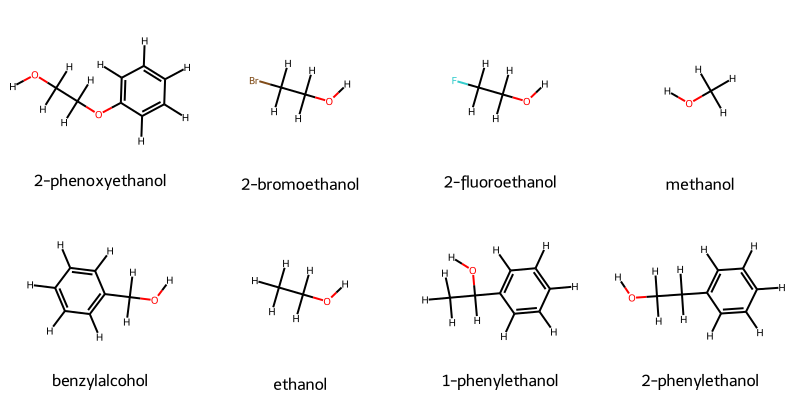

In [19]:
from rdkit.Chem import Draw

mols = df_alcohols["mol"].tolist()[:8]
legends = df_alcohols["Name"].astype(str).tolist()[:8]

Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(200, 200),
    legends=legends,
)


In [22]:

from mordred import Calculator, descriptors
calc = Calculator(descriptors , ignore_3D  = True )

print(calc)
print(calc.descriptors[:5])


(mordred.ABCIndex.ABCIndex(), mordred.ABCIndex.ABCGGIndex(), mordred.AcidBase.AcidicGroupCount(), mordred.AcidBase.BasicGroupCount(), mordred.AdjacencyMatrix.AdjacencyMatrix('SpAbs'))


In [24]:
all_descriptor_names = [desc.__class__.__name__ for desc in calc.descriptors]
print(f'the lengh of the descrptors is :{len(all_descriptor_names)}')

print(all_descriptor_names[:20])



the lengh of the descrptors is :1613
['ABCIndex', 'ABCGGIndex', 'AcidicGroupCount', 'BasicGroupCount', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AdjacencyMatrix', 'AromaticAtomsCount', 'AromaticBondsCount', 'AtomCount', 'AtomCount']


In [40]:
print(df_alcohols.columns.tolist())
print((df_alcohols.columns == "mol").sum())

['Name', 'Smiles', 'mol', 'mol', 'mol']
3


In [41]:
df_alcohols = df_alcohols.loc[:, ~df_alcohols.columns.duplicated()]

**Calculating descriptors for a single molecule**

In [50]:
import pandas as pd
import mordred
from rdkit import Chem

print(df_alcohols.columns)

if "mol" not in df_alcohols.columns:
    df_alcohols["mol"] = [
        Chem.AddHs(Chem.MolFromSmiles(s)) if s is not None else None
        for s in df_alcohols["Smiles"]
    ]

molecule = df_alcohols["mol"].iloc[50]
ac = mordred.Autocorrelation.ATS(2, "Z")

print(type(molecule))
print(ac(molecule))

Index(['Name', 'Smiles', 'mol'], dtype='object')
<class 'rdkit.Chem.rdchem.Mol'>
409.0


In [43]:
abc = mordred.ABCIndex.ABCIndex()
abc_1 = abc(df_alcohols['mol'][0])
print(abc_1)




7.071067811865477


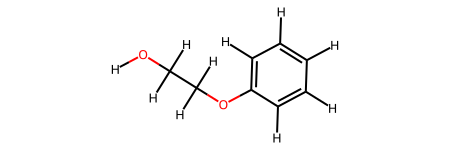

In [49]:
df_alcohols['mol'][0]


**Choose k < 6 menas we Slogp_VSA will give us the volume of atoms hydrphilics, if k > 6 the algo we give the atoms volume of hydrophobics**

In [54]:
desc = mordred.MoeType.SlogP_VSA(k=1)

valeurs = []
for mol in df_alcohols['mol']:
    if mol is None:
        valeurs.append(None)
        continue
    valeurs.append(desc(mol))

final_df = pd.concat(
    [df_alcohols['Smiles'].reset_index(drop=True),
     pd.DataFrame(valeurs, columns=['SlogP_VSA1'])],
    axis=1
)

final_df.head()


,Smiles,SlogP_VSA1
0,OCCOC1=CC=CC=C1,4.736863
1,BrCCO,0.000000
2,FCCO,0.000000
3,CO,0.000000
4,OCC1=CC=CC=C1,0.000000


In [59]:
valeurs = []

logp = mordred.MoeType.SlogP_VSA(k=1)
hba = mordred.HydrogenBond.HBondAcceptor()

for mol in df_alcohols['mol']:
    if mol is None:
        valeurs.append([None, None])
        continue

    desc = []
    desc.append(logp(mol))
    desc.append(hba(mol))
    valeurs.append(desc)

final_df = pd.concat(
    [df_alcohols['Smiles'].reset_index(drop=True),
     pd.DataFrame(valeurs, columns=['logp', 'hba'])],
    axis=1
)
final_df.head()

,Smiles,logp,hba
0,OCCOC1=CC=CC=C1,4.736863,2
1,BrCCO,0.000000,1
2,FCCO,0.000000,1
3,CO,0.000000,1
4,OCC1=CC=CC=C1,0.000000,1


In [ ]:
all_desc = Calculator(descriptors , ignore_3D= True).pandas(df['mol'])



100%|██████████| 14/14 [00:03<00:00,  3.80it/s]


In [62]:
all_desc.head()


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,4.352030,4.429961,0,0,7.465883,2.114908,3.975713,7.465883,1.244314,2.707505,...,7.788626,44.534727,81.057849,6.235219,26,2,26.0,27.0,2.111111,1.416667
1,3.535534,3.535534,0,0,6.472136,2.000000,3.618034,6.472136,1.294427,2.525424,...,7.147559,41.004802,67.042199,6.704220,15,0,20.0,20.0,1.250000,1.250000
2,4.242641,4.000000,0,0,8.000000,2.000000,4.000000,8.000000,1.333333,2.687624,...,7.627057,30.941317,79.042199,7.185654,27,3,24.0,24.0,1.500000,1.500000
3,5.059137,4.785854,0,0,8.720566,2.101003,4.202006,8.720566,1.245795,2.844305,...,8.124151,33.544698,93.057849,6.646989,42,5,30.0,31.0,2.361111,1.666667
4,5.059137,4.785854,0,0,8.720566,2.101003,4.202006,8.720566,1.245795,2.844305,...,8.124151,33.544698,93.057849,6.646989,42,5,30.0,31.0,2.361111,1.666667


In [65]:

df_final = pd.concat([df['Smiles'], all_desc], axis=1)
df_final.head()


,Smiles,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,CN1C=CC=C1,4.352030,4.429961,0,0,7.465883,2.114908,3.975713,7.465883,1.244314,...,7.788626,44.534727,81.057849,6.235219,26,2,26.0,27.0,2.111111,1.416667
1,C1=CC=CN1,3.535534,3.535534,0,0,6.472136,2.000000,3.618034,6.472136,1.294427,...,7.147559,41.004802,67.042199,6.704220,15,0,20.0,20.0,1.250000,1.250000
2,C1=CN=CC=C1,4.242641,4.000000,0,0,8.000000,2.000000,4.000000,8.000000,1.333333,...,7.627057,30.941317,79.042199,7.185654,27,3,24.0,24.0,1.500000,1.500000
3,CC1=NC=CC=C1,5.059137,4.785854,0,0,8.720566,2.101003,4.202006,8.720566,1.245795,...,8.124151,33.544698,93.057849,6.646989,42,5,30.0,31.0,2.361111,1.666667
4,CC1=CC=NC=C1,5.059137,4.785854,0,0,8.720566,2.101003,4.202006,8.720566,1.245795,...,8.124151,33.544698,93.057849,6.646989,42,5,30.0,31.0,2.361111,1.666667


In [66]:
df_final.to_excel('final.xlsx' , index = None)


In [67]:
mol_list_alcohols = []
for mol in df_alcohols['Smiles'] : 

    mol = Chem.MolFromSmiles(mol)
    mol = Chem.AddHs(mol)
    mol_list_alcohols.append(mol)

df_alcohols = pd.concat([df_alcohols, pd.DataFrame(mol_list_alcohols, columns = (['mol']))], axis=1)

print(df_alcohols.head(10))


               Name            Smiles  \
0  2-phenoxyethanol   OCCOC1=CC=CC=C1   
1    2-bromoethanol             BrCCO   
2   2-fluoroethanol              FCCO   
3          methanol                CO   
4     benzylalcohol     OCC1=CC=CC=C1   
5           ethanol               CCO   
6   1-phenylethanol  OC(C)C1=CC=CC=C1   
7   2-phenylethanol    OCCC1=CC=CC=C1   
8  2-methoxyethanol             OCCOC   
9   2-ethoxyethanol            OCCOCC   

                                                 mol  \
0  <rdkit.Chem.rdchem.Mol object at 0x000001DFF99...   
1  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
2  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
3  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
4  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
5  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
6  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
7  <rdkit.Chem.rdchem.Mol object at 0x000001DFF9A...   
8  <rdkit.Chem.rdchem.Mol object at 0x000001

In [79]:

from mordred import Calculator, descriptors
calc = Calculator(descriptors , ignore_3D  = False )

print(calc)
print(calc.descriptors[:5])
print(f'the all descriptors metrics is :{calc.descriptors}')
len(calc.descriptors)


(mordred.ABCIndex.ABCIndex(), mordred.ABCIndex.ABCGGIndex(), mordred.AcidBase.AcidicGroupCount(), mordred.AcidBase.BasicGroupCount(), mordred.AdjacencyMatrix.AdjacencyMatrix('SpAbs'))
the all descriptors metrics is :(mordred.ABCIndex.ABCIndex(), mordred.ABCIndex.ABCGGIndex(), mordred.AcidBase.AcidicGroupCount(), mordred.AcidBase.BasicGroupCount(), mordred.AdjacencyMatrix.AdjacencyMatrix('SpAbs'), mordred.AdjacencyMatrix.AdjacencyMatrix('SpMax'), mordred.AdjacencyMatrix.AdjacencyMatrix('SpDiam'), mordred.AdjacencyMatrix.AdjacencyMatrix('SpAD'), mordred.AdjacencyMatrix.AdjacencyMatrix('SpMAD'), mordred.AdjacencyMatrix.AdjacencyMatrix('LogEE'), mordred.AdjacencyMatrix.AdjacencyMatrix('VE1'), mordred.AdjacencyMatrix.AdjacencyMatrix('VE2'), mordred.AdjacencyMatrix.AdjacencyMatrix('VE3'), mordred.AdjacencyMatrix.AdjacencyMatrix('VR1'), mordred.AdjacencyMatrix.AdjacencyMatrix('VR2'), mordred.AdjacencyMatrix.AdjacencyMatrix('VR3'), mordred.Aromatic.AromaticAtomsCount(), mordred.Aromatic.Aromat

1826

In [92]:
df_alcohols = df_alcohols.loc[:, ~df_alcohols.columns.duplicated()]

None


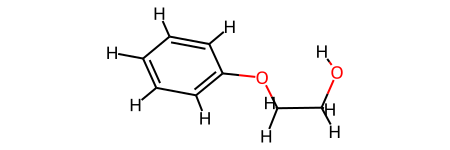

In [96]:
def generate_3d_2d(mol) : 
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

print(generate_3d_2d(df_alcohols['mol'][0]))

df_alcohols['mol'][0]
    



**$$d(i, j) = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2 + (z_i - z_j)^2}$$**
**$$\text{Diameter3D} = \max_{i, j} \left( d(i, j) \right)$$**
compute the max d between each two atoms in one molecule

In [102]:

# Calculating descriptors for a single molecule
dia = mordred.GeometricalIndex.Diameter3D()

import numpy as np 
dia(df_alcohols['mol'][0])

np.float64(8.284303256850405)